In [1]:
import pandas as pd
import numpy as np
np.set_printoptions(precision=6, suppress=True)
from sklearn.utils import shuffle

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import *
import tensorflow_addons as tfa
tf.__version__

'2.3.0'

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

In [3]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [5]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)

2 Physical GPUs, 2 Logical GPUs


In [6]:
strategy = tf.distribute.MirroredStrategy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


# Hyperparameters

In [7]:
PRE_TRAINED = './models/ResNet.h5'
BEST_PATH = './models/resnet_transfer.h5'
TRAINING_EPOCHS = 200
LEARNING_RATE = 0.002
EPSILON = 1e-06
BATCH_SIZE = 16

# Data loading

In [8]:
l = np.load('./results/2020_W/fw_ct_dataset.npz', allow_pickle=True)
data_indices = l['data_indices']
input_data = l['input_data']
output_label = l['output_label']
INPUT_MAXS = l['INPUT_MAXS']
INPUT_MINS = l['INPUT_MINS']
OUTPUT_MAX = l['OUTPUT_MAX']
OUTPUT_MIN = l['OUTPUT_MIN']

In [9]:
input_data = input_data.astype('float32')
output_label = output_label.astype('float32')

In [10]:
print(input_data.shape)
print(output_label.shape)

(456, 144, 9)
(456, 1)


In [11]:
print(INPUT_MAXS)
print(INPUT_MINS)

[  41.4725   99.     1313.3      78.755     7.857     4.908    35.39
   55.877    16.802 ]
[11.5    16.435  -0.5957 63.447   0.205   0.112  11.53   40.295  11.506 ]


In [12]:
print(OUTPUT_MAX)
print(OUTPUT_MIN)

1.9478683859198707
0.4452854713085716


In [13]:
# data_indices, input_data, output_label = shuffle(data_indices, input_data, output_label, random_state=3101)

In [14]:
N_TRAIN = int(input_data.shape[0]*.1)
N_DEV = int(input_data.shape[0]/3)
TRAIN_INDEX = [_ for _ in range(N_TRAIN)] + \
              [_ for _ in range(N_DEV, N_DEV+N_TRAIN)] + \
              [_ for _ in range(N_DEV*2, N_DEV*2+N_TRAIN)]
VAL_INDEX = [_ for _ in range(input_data.shape[0]) if _ not in TRAIN_INDEX]
train_input = input_data[TRAIN_INDEX, ...]
train_label = output_label[TRAIN_INDEX, ...]
train_indices = data_indices[TRAIN_INDEX]
val_input = input_data[VAL_INDEX, ...]
val_label = output_label[VAL_INDEX, ...]
val_indices = data_indices[VAL_INDEX]

In [15]:
print(f'number of data set: {input_data.shape[0]}')
print(f'number of training set: {train_input.shape[0]}')
print(f'number of validation set: {val_input.shape[0]}')

number of data set: 456
number of training set: 135
number of validation set: 321


In [16]:
with strategy.scope():
    train_dataset = tf.data.Dataset.from_tensor_slices((train_input, train_label))
    train_dataset = train_dataset.cache().shuffle(BATCH_SIZE*10).batch(BATCH_SIZE, drop_remainder=False)
    val_dataset = tf.data.Dataset.from_tensor_slices((val_input, val_label))
    val_dataset = val_dataset.cache().shuffle(BATCH_SIZE*10).batch(BATCH_SIZE, drop_remainder=False)

# Model construction

In [17]:
class ResidualBlock(layers.Layer):
    def __init__(self, num_filter, stride=1):
        super(ResidualBlock, self).__init__()
        self.n = num_filter
        self.s = stride
        
        self.conv1 = layers.Conv1D(filters=self.n, kernel_size=1, strides=1, kernel_initializer='glorot_normal', padding='same')
        self.norm1 = layers.BatchNormalization()
        self.act1 = layers.Activation(activations.relu)
        self.conv2 = layers.Conv1D(filters=self.n, kernel_size=3, strides=stride, kernel_initializer='glorot_normal', padding='same')
        self.norm2 = layers.BatchNormalization()
        self.act2 = layers.Activation(activations.relu)
        self.conv3 = layers.Conv1D(filters=self.n*4, kernel_size=1, strides=1, kernel_initializer='glorot_normal', padding='same')
        self.norm3 = layers.BatchNormalization()
        self.act3 = layers.Activation(activations.relu)

        self.downsample = Sequential()
        self.downsample.add(layers.Conv1D(filters=self.n*4, kernel_size=1, strides=stride, kernel_initializer='glorot_normal'))
        self.downsample.add(layers.BatchNormalization())

    def call(self, inp, training=None, **kwargs):
        shortcut = self.downsample(inp)

        inp = self.act1(self.norm1(self.conv1(inp), training=training))
        inp = self.act2(self.norm2(self.conv2(inp), training=training))
        inp = self.norm3(self.conv3(inp), training=training)

        oup = self.act3(layers.add([shortcut, inp]))

        return oup

In [18]:
def block_maker(num_filter, num_blocks, stride=1):
    res_block = tf.keras.Sequential()
    res_block.add(ResidualBlock(num_filter, stride=stride))

    for _ in range(1, num_blocks):
        res_block.add(ResidualBlock(num_filter, stride=1))

    return res_block

In [19]:
class ResNet1D(Model):
    def __init__(self, layer_params):
        super(ResNet1D, self).__init__()
        self.conv1 = layers.Conv1D(filters=64, kernel_size=7, strides=2, kernel_initializer='glorot_normal', padding="same")
        self.norm1 = layers.BatchNormalization()
        self.act1 = layers.Activation(activations.relu)
        self.pool1 = layers.MaxPool1D(pool_size=3, strides=2, padding="same")

        self.layer1 = block_maker(num_filter=64, num_blocks=layer_params[0])
        self.layer2 = block_maker(num_filter=128, num_blocks=layer_params[1], stride=2)
        self.layer3 = block_maker(num_filter=256, num_blocks=layer_params[2], stride=2)
        self.layer4 = block_maker(num_filter=512, num_blocks=layer_params[3], stride=2)

#         self.avgpool = layers.GlobalAveragePooling1D()
        self.flat = layers.Flatten()
        self.dense1 = layers.Dense(units=512, activation=activations.sigmoid)
        self.dense2 = layers.Dense(units=128, activation=activations.sigmoid)
        self.fc = layers.Dense(units=1, activation=activations.sigmoid)

    def call(self, inp, training=None, mask=None):
        inp = self.conv1(inp)
        inp = self.norm1(inp, training=training)
        inp = self.act1(inp)
        inp = self.pool1(inp)
        inp = self.layer1(inp, training=training)
        inp = self.layer2(inp, training=training)
        inp = self.layer3(inp, training=training)
        inp = self.layer4(inp, training=training)
#         inp = self.avgpool(inp)
        inp = self.dense1(self.flat(inp))
        inp = self.dense2(inp)
        output = self.fc(inp)

        return output

In [20]:
cbs = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=.5, patience=2, verbose=0, mode='min',
    min_delta=0.0001, cooldown=0, min_lr=0)

save = callbacks.ModelCheckpoint(
    BEST_PATH, monitor='val_loss', verbose=0,
    save_best_only=True, save_weights_only=True, mode='min', save_freq='epoch')

early_stop = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=20) 

In [21]:
with strategy.scope():
    model = ResNet1D(layer_params=[1, 2, 1, 1])
    opt = optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=EPSILON)
    model.compile(optimizer=opt, loss='mae')
    model.predict(val_dataset)
    model.load_weights(PRE_TRAINED)

Instructions for updating:
Use `tf.data.Iterator.get_next_as_optional()` instead.
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then br

In [22]:
model.trainable = False

In [23]:
base_model = Sequential(model.layers[:-3])
prediction_layer1 = layers.Dense(512)
prediction_layer2 = layers.Dense(128)
prediction_layer3 = layers.Dense(1)

In [24]:
new_model = Sequential([
    base_model,
    prediction_layer1,
    prediction_layer2,
    prediction_layer3    
])

In [25]:
with strategy.scope():
    opt = optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=EPSILON)
    new_model.compile(optimizer=opt, loss='mae')
    new_model.fit(train_dataset, epochs=TRAINING_EPOCHS, validation_data=val_dataset,
                  verbose=1, callbacks=[cbs, save, early_stop]) 

Epoch 1/200
INFO:tensorflow:batch_all_reduce: 6 all-reduces with algorithm = nccl, num_packs = 1
INFO:tensorflow:batch_all_reduce: 6 all-reduces with algorithm = nccl, num_packs = 1
9/9 [==============================] - 2s 232ms/step - loss: 76.3633 - val_loss: 52.8056
Epoch 2/200
9/9 [==============================] - 1s 77ms/step - loss: 13.7326 - val_loss: 7.5190
Epoch 3/200
9/9 [==============================] - 0s 53ms/step - loss: 9.9085 - val_loss: 19.9697
Epoch 4/200
9/9 [==============================] - 1s 77ms/step - loss: 3.2125 - val_loss: 6.7259
Epoch 5/200
9/9 [==============================] - 1s 78ms/step - loss: 2.3152 - val_loss: 2.5983
Epoch 6/200
9/9 [==============================] - 0s 51ms/step - loss: 1.4019 - val_loss: 10.1859
Epoch 7/200
9/9 [==============================] - 0s 51ms/step - loss: 1.4495 - val_loss: 7.6905
Epoch 8/200
9/9 [==============================] - 1s 79ms/step - loss: 0.6770 - val_loss: 0.9246
Epoch 9/200
9/9 [=======================

In [26]:
pred_output = new_model.predict(val_input)

In [27]:
pred_output = pred_output*(OUTPUT_MAX - OUTPUT_MIN) + OUTPUT_MIN
val_label = val_label*(OUTPUT_MAX - OUTPUT_MIN) + OUTPUT_MIN

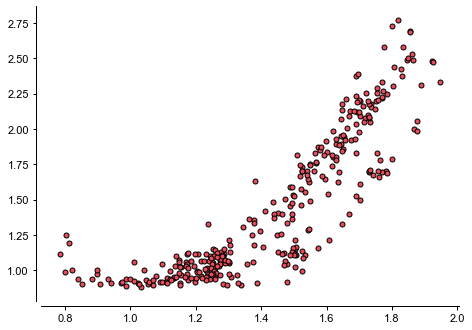

In [28]:
fig = plt.figure(figsize=((8.5/2.54*2), (6/2.54*2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(val_label, pred_output, 'o', ms=5, mec='k', c=cmap[0])


fig.tight_layout()

In [29]:
pred_df = pd.DataFrame(val_label, index=val_indices[:, 0], columns=['label'])
pred_df['pred'] = pred_output
pred_df.index = pd.DatetimeIndex(pred_df.index)

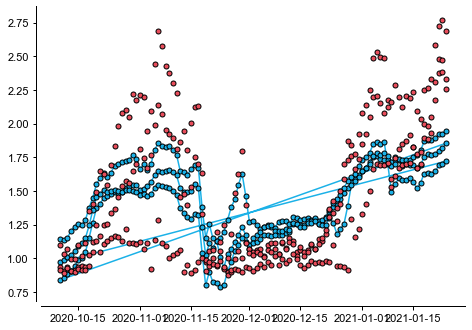

In [30]:
fig = plt.figure(figsize=((8.5/2.54*2), (6/2.54*2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(pred_df.index, pred_df['label'], '-o', ms=5, mec='k', c=cmap[4])
ax0.plot(pred_df.index, pred_df['pred'], 'o', ms=5, mec='k', c=cmap[0])


fig.tight_layout()

In [31]:
pred_df.to_csv('./results/model_output/convnet1d_tf.csv')